In [1]:
# === Setup & helpers ===
# Load data, parse compositions, and precompute element stats used by multiple visualizations.

import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your CSV
DATA_PATH = "./data/mxene_mp.csv"
df = pd.read_csv(DATA_PATH)

# Parse 'composition' (JSON-like string) → dict, and compute element fractions
def parse_comp_dict(comp_str):
    try:
        d = json.loads(comp_str)
        tot = sum(d.values())
        if tot == 0:
            return {}
        return {el: float(n) / float(tot) for el, n in d.items()}
    except Exception:
        return {}

df["comp_dict"] = df["composition"].apply(parse_comp_dict)

# Element appearance counts (how many materials contain the element)
element_counts = {}
for comp in df["comp_dict"]:
    for el in comp.keys():
        element_counts[el] = element_counts.get(el, 0) + 1

element_freq = pd.DataFrame(
    {"element": list(element_counts.keys()), "count": list(element_counts.values())}
).sort_values("count", ascending=False).reset_index(drop=True)

# Build composition vectors (rows = materials, cols = top-N most frequent elements)
TOPN = 100  # adjust if you want richer descriptors
top_elements = element_freq["element"].head(TOPN).tolist()

def comp_to_row(comp_dict, elems):
    return [comp_dict.get(el, 0.0) for el in elems]

X_comp = np.array([comp_to_row(cd, top_elements) for cd in df["comp_dict"]])

# Targets
y_eform = df["formation_energy_per_atom"].values
y_gap = df["band_gap"].values

print("Rows:", len(df), "| Unique elements:", len(element_counts), "| Top elements:", top_elements[:10], "...")


Rows: 6419 | Unique elements: 68 | Top elements: ['N', 'C', 'O', 'H', 'Fe', 'S', 'Co', 'Mn', 'Cl', 'Li'] ...


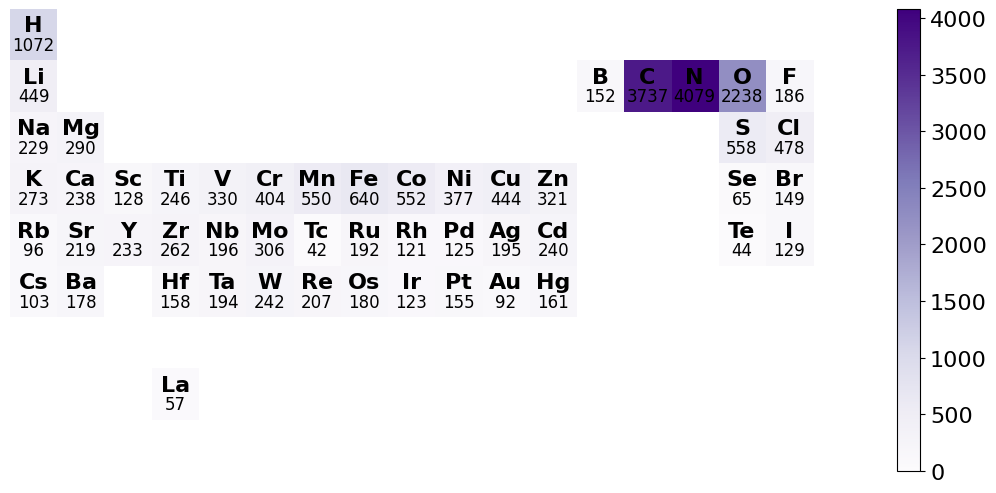

In [2]:
# === Periodic-table heatmap — clean version (no grid, no axes) ===
from matplotlib.colors import LogNorm
import os
os.makedirs("./visual", exist_ok=True)
font_size = 16

# ----- controls -----
cmap_name        = "Purples"   # e.g., "Reds", "Purples", "viridis"
use_log_scale    = False
vmin             = 0
vmax             = None
annotate_symbol  = True
annotate_counts  = True
fontsize_symbol  = 16
fontsize_count   = 12
period1_on_top   = True

pt_positions = {
    # period 1
    "H": (1, 1), "He": (1, 18),
    # period 2
    "Li": (2, 1), "Be": (2, 2), "B": (2, 13), "C": (2, 14), "N": (2, 15), "O": (2, 16), "F": (2, 17), "Ne": (2, 18),
    # period 3
    "Na": (3, 1), "Mg": (3, 2), "Al": (3, 13), "Si": (3, 14), "P": (3, 15), "S": (3, 16), "Cl": (3, 17), "Ar": (3, 18),
    # period 4
    "K": (4, 1), "Ca": (4, 2), "Sc": (4, 3), "Ti": (4, 4), "V": (4, 5), "Cr": (4, 6), "Mn": (4, 7),
    "Fe": (4, 8), "Co": (4, 9), "Ni": (4,10), "Cu": (4,11), "Zn": (4,12), "Ga": (4,13), "Ge": (4,14), "As": (4,15),
    "Se": (4,16), "Br": (4,17), "Kr": (4,18),
    # period 5
    "Rb": (5, 1), "Sr": (5, 2), "Y": (5, 3), "Zr": (5, 4), "Nb": (5, 5), "Mo": (5, 6), "Tc": (5, 7),
    "Ru": (5, 8), "Rh": (5, 9), "Pd": (5,10), "Ag": (5,11), "Cd": (5,12), "In": (5,13), "Sn": (5,14), "Sb": (5,15),
    "Te": (5,16), "I": (5,17), "Xe": (5,18),
    # period 6
    "Cs": (6, 1), "Ba": (6, 2), "La": (8, 4), "Hf": (6, 4), "Ta": (6, 5), "W": (6, 6), "Re": (6, 7),
    "Os": (6, 8), "Ir": (6, 9), "Pt": (6,10), "Au": (6,11), "Hg": (6,12), "Tl": (6,13), "Pb": (6,14), "Bi": (6,15),
    # period 7
    "Fr": (7, 1), "Ra": (7, 2), "Ac": (9, 4)
}

# Build grid of raw counts
rows, cols = 9, 18
grid = np.full((rows, cols), np.nan, dtype=float)
count_map = dict(zip(element_freq["element"], element_freq["count"]))
for el, (period, group) in pt_positions.items():
    if el in count_map:
        grid[period - 1, group - 1] = float(count_map[el])

data = np.ma.masked_invalid(grid)
cmap = plt.get_cmap(cmap_name).copy()

if vmin is None:
    vmin = np.nanmin(grid)
if vmax is None:
    vmax = np.nanmax(grid)

norm = LogNorm(vmin=max(vmin, 1e-9), vmax=max(vmax, 1e-9)) if use_log_scale else None
origin = "upper" if period1_on_top else "lower"

plt.figure(figsize=(12, 6))
im = plt.imshow(
    data,
    aspect="auto",
    cmap=cmap,
    norm=norm if use_log_scale else None,
    vmin=None if use_log_scale else vmin,
    vmax=None if use_log_scale else vmax,
    origin=origin,
)

# Remove axis ticks and labels
plt.xticks([])
plt.yticks([])
plt.xlabel("")
plt.ylabel("")
plt.box(False)

# Colorbar
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=16)  # tick font size

# Annotations
for el, (period, group) in pt_positions.items():
    val = grid[period - 1, group - 1]
    if not np.isnan(val):
        x, y = group - 1, period - 1
        if annotate_symbol:
            plt.text(x, y - 0.18, el, ha="center", va="center",
                     fontsize=fontsize_symbol, fontweight="bold")
        if annotate_counts:
            plt.text(x, y + 0.20, f"{int(val)}", ha="center", va="center",
                     fontsize=fontsize_count)

plt.savefig('./visual/fig1a.jpg', format='jpg', dpi=1000, bbox_inches='tight')
plt.show()


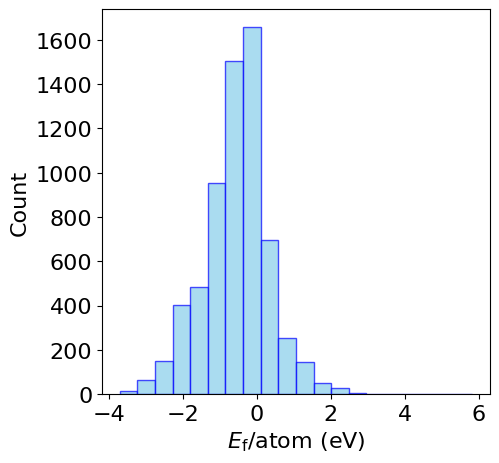

In [3]:
# Histograms for formation energy

plt.figure(figsize=(5, 5))
plt.hist(df["formation_energy_per_atom"].dropna().values,
             bins=20,
             color='skyblue',
             edgecolor='blue',
             alpha=0.7
             )
plt.xlabel(r"$E_\mathrm{f}$/atom (eV)", fontsize=font_size)
plt.ylabel("Count", fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.savefig('./visual/fig1b.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()

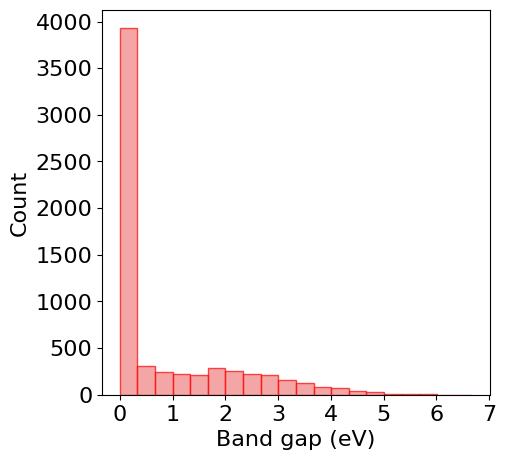

In [4]:
# Histograms for band gap

plt.figure(figsize=(5, 5))
plt.hist(df["band_gap"].dropna().values,
             bins=20,
             color='lightcoral',
             edgecolor='red',
             alpha=0.7
             )
plt.xlabel("Band gap (eV)", fontsize=font_size)
plt.ylabel("Count", fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.savefig('./visual/fig1c.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()
